# Model Visualization
1. Weight heatmaps (attention, FFN, embeddings)
2. 2D embedding projection for selected words

In [3]:
!pip install -q matplotlib scikit-learn

In [4]:
import os, json, torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from tokenizers import Tokenizer
from google.colab import drive

drive.mount('/content/drive')

SPARKYLLM = "/content/drive/MyDrive/sparkyllm"
CHECKPOINT_PATH = os.path.join(SPARKYLLM, "checkpoints", "gpt_medium_phase2.pth")
TOKENIZER_PATH = os.path.join(SPARKYLLM, "datasets_pretrain", "tokenizer_out", "tokenizer.json")
META_PATH = os.path.join(SPARKYLLM, "datasets_pretrain", "tokenizer_out", "train_long_meta.json")

# Load checkpoint (raw state dict, no model class needed for visualization)
state_dict = torch.load(CHECKPOINT_PATH, map_location="cpu")
state_dict = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}

# Load tokenizer
tokenizer = Tokenizer.from_file(TOKENIZER_PATH)
with open(META_PATH) as f:
    meta = json.load(f)
VOCAB_SIZE = int(meta["vocab_size"])

print(f"Loaded {len(state_dict)} tensors")
print(f"Tokenizer vocab: {VOCAB_SIZE}")

Mounted at /content/drive
Loaded 293 tensors
Tokenizer vocab: 32000


## 1. Weight Visualization

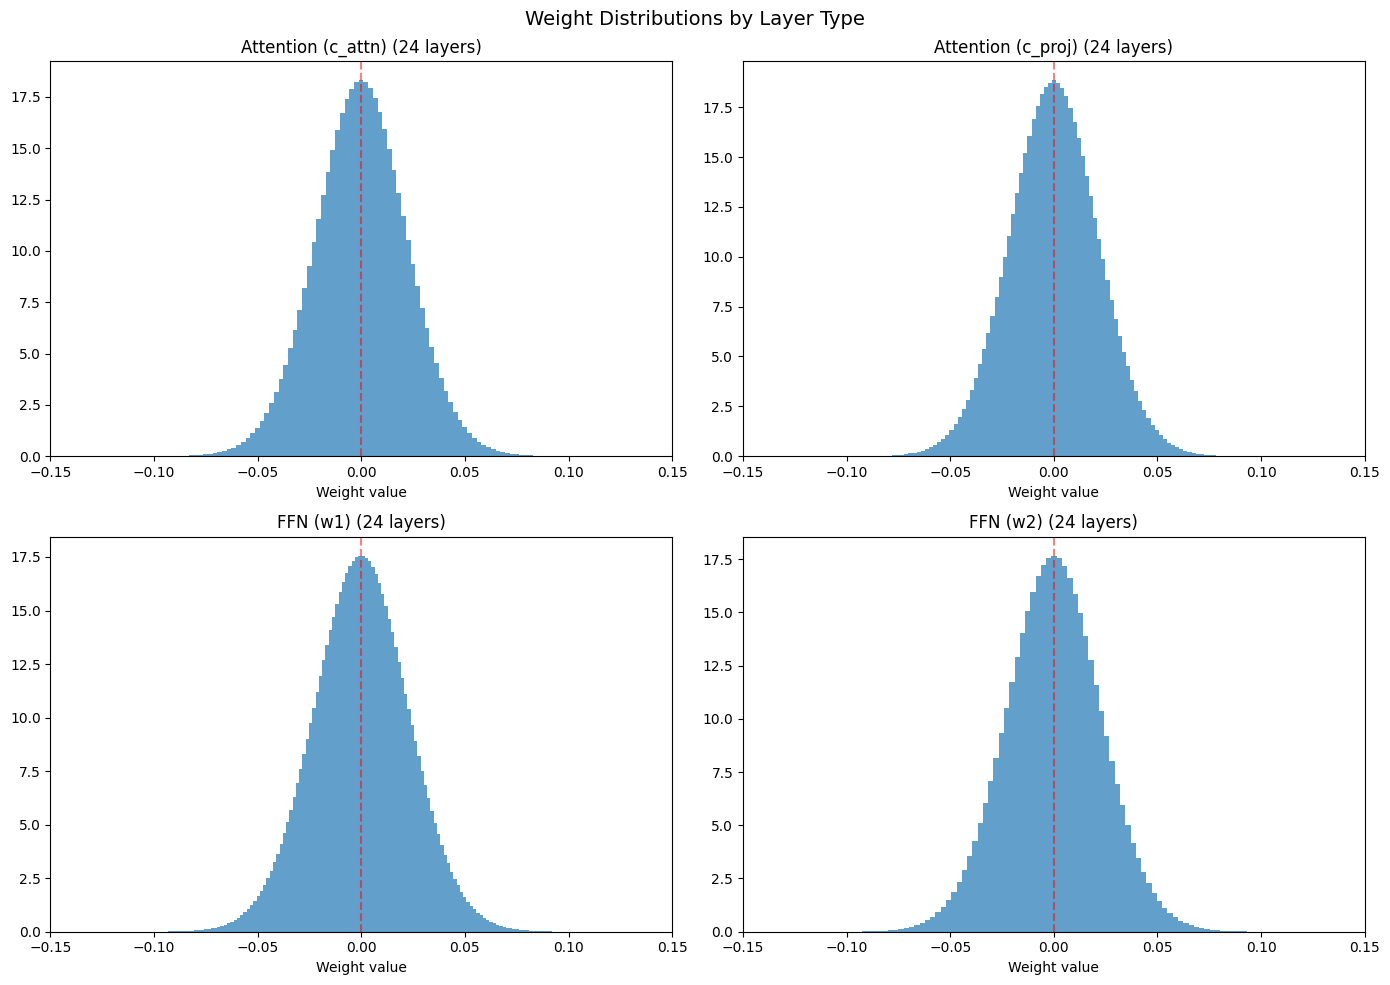

In [5]:
# Overview: distribution of all weight matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gather stats per layer type
layer_types = {
    "Attention (c_attn)": [v for k, v in state_dict.items() if "c_attn.weight" in k],
    "Attention (c_proj)": [v for k, v in state_dict.items() if "c_proj.weight" in k],
    "FFN (w1)": [v for k, v in state_dict.items() if "ff.w1.weight" in k],
    "FFN (w2)": [v for k, v in state_dict.items() if "ff.w2.weight" in k],
}

for ax, (name, weights) in zip(axes.flat, layer_types.items()):
    all_vals = torch.cat([w.flatten() for w in weights]).numpy()
    ax.hist(all_vals, bins=200, density=True, alpha=0.7)
    ax.set_title(f"{name} ({len(weights)} layers)")
    ax.set_xlabel("Weight value")
    ax.axvline(x=0, color='r', linestyle='--', alpha=0.5)
    ax.set_xlim(-0.15, 0.15)

plt.suptitle("Weight Distributions by Layer Type", fontsize=14)
plt.tight_layout()
plt.show()

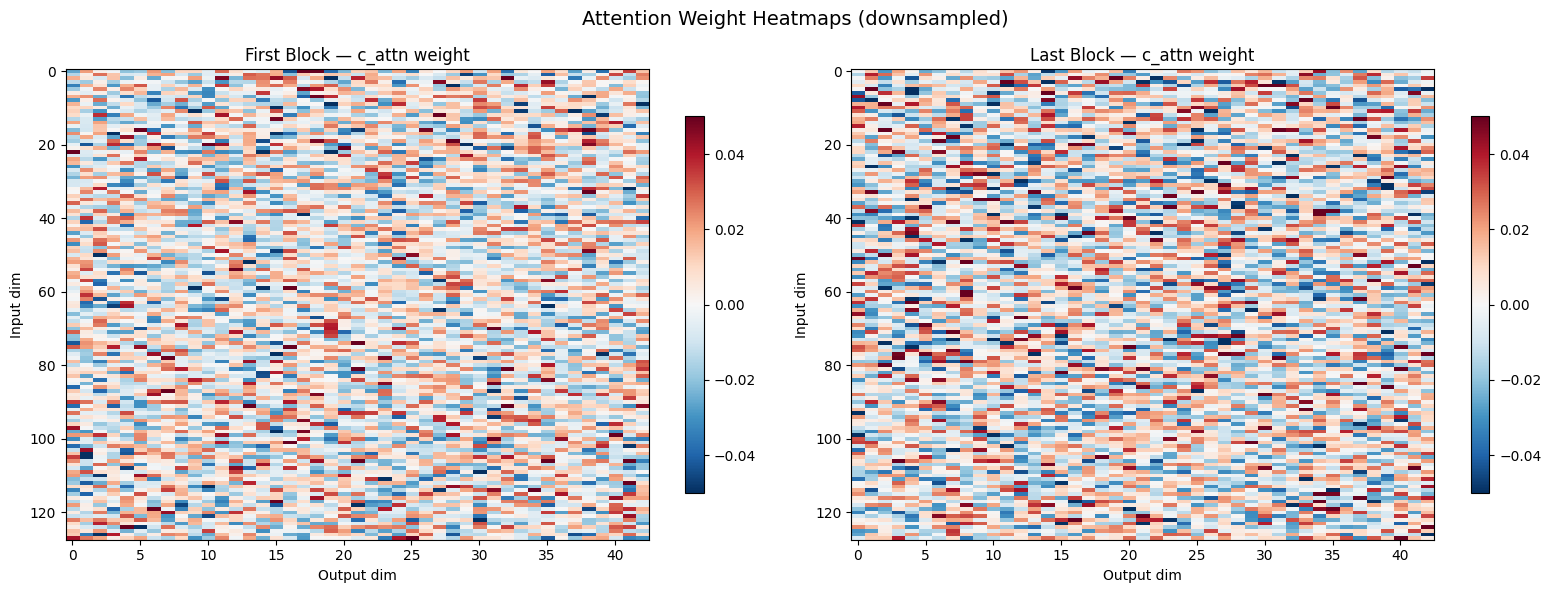

In [6]:
# Heatmap: attention weights for first and last transformer block
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, block_idx, label in [(axes[0], 0, "First Block"), (axes[1], 23, "Last Block")]:
    key = f"blocks.{block_idx}.attn.c_attn.weight"
    if key in state_dict:
        w = state_dict[key].float().numpy()
        # Downsample for visibility (full matrix is 1280x3840)
        step = max(1, w.shape[0] // 128)
        w_small = w[::step, ::step]
        im = ax.imshow(w_small, cmap="RdBu_r", aspect="auto", vmin=-0.05, vmax=0.05)
        ax.set_title(f"{label} — c_attn weight")
        ax.set_xlabel("Output dim")
        ax.set_ylabel("Input dim")
        plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("Attention Weight Heatmaps (downsampled)", fontsize=14)
plt.tight_layout()
plt.show()

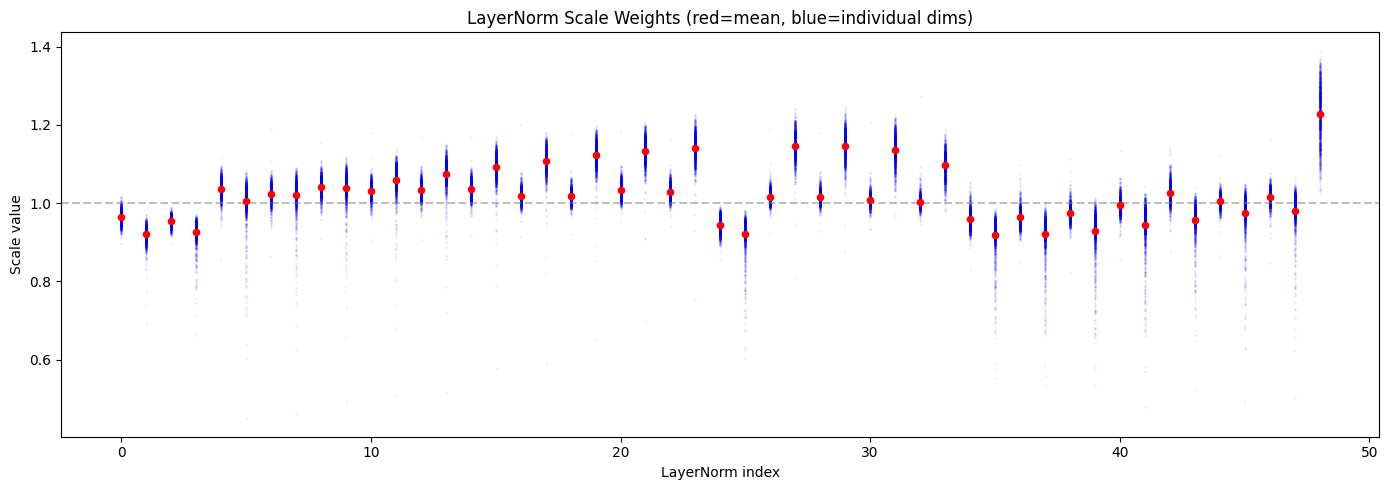

In [7]:
# LayerNorm: how much does each layer rescale?
norm_weights = {k: v for k, v in state_dict.items() if "norm" in k and "weight" in k}

fig, ax = plt.subplots(figsize=(14, 5))
for i, (name, w) in enumerate(sorted(norm_weights.items())):
    vals = w.float().numpy()
    short_name = name.replace("blocks.", "B").replace(".norm", " N").replace(".weight", "")
    ax.scatter([i] * len(vals), vals, alpha=0.05, s=1, c='blue')
    ax.scatter(i, vals.mean(), c='red', s=20, zorder=5)

ax.set_xlabel("LayerNorm index")
ax.set_ylabel("Scale value")
ax.set_title("LayerNorm Scale Weights (red=mean, blue=individual dims)")
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 2. Embedding Visualization (t-SNE)

In [8]:
# Words to visualize — edit this list!
WORDS = [
    # People / characters
    "king", "queen", "prince", "princess", "knight", "soldier",
    # Emotions
    "love", "hate", "fear", "joy", "anger", "sorrow",
    # Nature
    "mountain", "river", "forest", "ocean", "sun", "moon",
    # Actions
    "fight", "run", "speak", "write", "think", "dream",
    # Objects
    "sword", "book", "gold", "stone", "fire", "water",
    # Abstract
    "truth", "death", "power", "freedom", "justice", "god",
]

# Get embedding matrix (shared with lm_head via weight tying)
embed_weight = state_dict["token_embedding.weight"].float().numpy()
print(f"Embedding matrix: {embed_weight.shape}")

# Map words to embeddings — average all subword embeddings for split words
categories = {
    "People": ["king", "queen", "prince", "princess", "knight", "soldier"],
    "Emotions": ["love", "hate", "fear", "joy", "anger", "sorrow"],
    "Nature": ["mountain", "river", "forest", "ocean", "sun", "moon"],
    "Actions": ["fight", "run", "speak", "write", "think", "dream"],
    "Objects": ["sword", "book", "gold", "stone", "fire", "water"],
    "Abstract": ["truth", "death", "power", "freedom", "justice", "god"],
}

word_embeddings = []
word_labels = []
word_categories = []

for cat, words in categories.items():
    for word in words:
        ids = tokenizer.encode(word).ids
        # Average all subword embeddings for this word
        vecs = embed_weight[[i for i in ids if i < embed_weight.shape[0]]]
        avg_vec = vecs.mean(axis=0)
        word_embeddings.append(avg_vec)

        if len(ids) == 1:
            word_labels.append(word)
        else:
            pieces = [tokenizer.decode([i]) for i in ids]
            word_labels.append(f"{word} ({'|'.join(pieces)})")
        word_categories.append(cat)

word_embeddings = np.array(word_embeddings)
print(f"Mapped {len(word_labels)} words to averaged embeddings")

# Show which words are split
split_count = 0
for label, cat in zip(word_labels, word_categories):
    if "|" in label:
        split_count += 1
        print(f"  SPLIT: {cat:10s} | {label}")
if split_count:
    print(f"\n  {split_count} words split by BPE — using averaged subword embeddings")
else:
    print("  All words are single tokens")

Embedding matrix: (32000, 1280)
Mapped 36 words to averaged embeddings
  SPLIT: People     | queen (que|en)
  SPLIT: People     | prince (pr|ince)
  SPLIT: People     | princess (pr|incess)
  SPLIT: People     | knight (k|night)
  SPLIT: People     | soldier (s|old|ier)
  SPLIT: Emotions   | hate (h|ate)
  SPLIT: Emotions   | fear (f|ear)
  SPLIT: Emotions   | sorrow (s|orrow)
  SPLIT: Nature     | mountain (mount|ain)
  SPLIT: Nature     | river (ri|ver)
  SPLIT: Nature     | ocean (o|cean)
  SPLIT: Actions    | speak (spe|ak)
  SPLIT: Objects    | sword (sw|ord)
  SPLIT: Abstract   | truth (tr|uth)
  SPLIT: Abstract   | death (de|ath)
  SPLIT: Abstract   | freedom (f|reedom)
  SPLIT: Abstract   | justice (just|ice)
  SPLIT: Abstract   | god (g|od)

  18 words split by BPE — using averaged subword embeddings


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


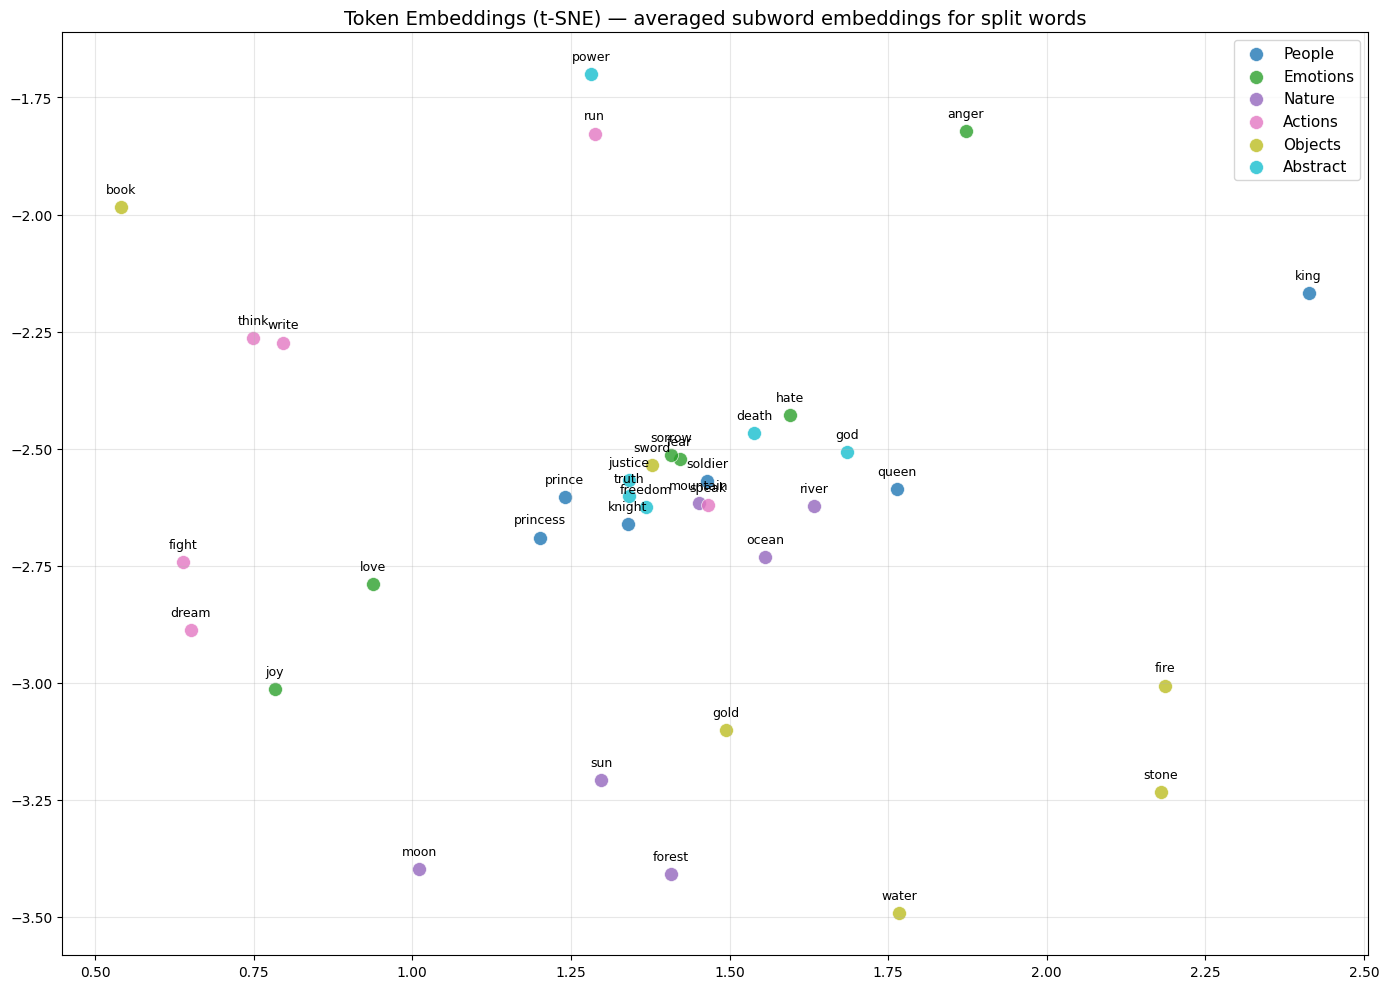

In [9]:
# t-SNE projection
perplexity = min(30, len(word_embeddings) - 1)
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, n_iter=2000)
coords = tsne.fit_transform(word_embeddings)

# Plot
cat_list = list(categories.keys())
colors = plt.cm.tab10(np.linspace(0, 1, len(cat_list)))
cat_to_color = {cat: colors[i] for i, cat in enumerate(cat_list)}

fig, ax = plt.subplots(figsize=(14, 10))

for cat in cat_list:
    mask = [c == cat for c in word_categories]
    xs = coords[mask, 0]
    ys = coords[mask, 1]
    ax.scatter(xs, ys, c=[cat_to_color[cat]], label=cat, s=100, alpha=0.8, edgecolors='white', linewidth=0.5)

for i, label in enumerate(word_labels):
    # Show just the word (strip BPE pieces for cleaner labels)
    display = label.split(" (")[0]
    ax.annotate(display, (coords[i, 0], coords[i, 1]),
                fontsize=9, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

ax.legend(fontsize=11, loc='best')
ax.set_title("Token Embeddings (t-SNE) — averaged subword embeddings for split words", fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

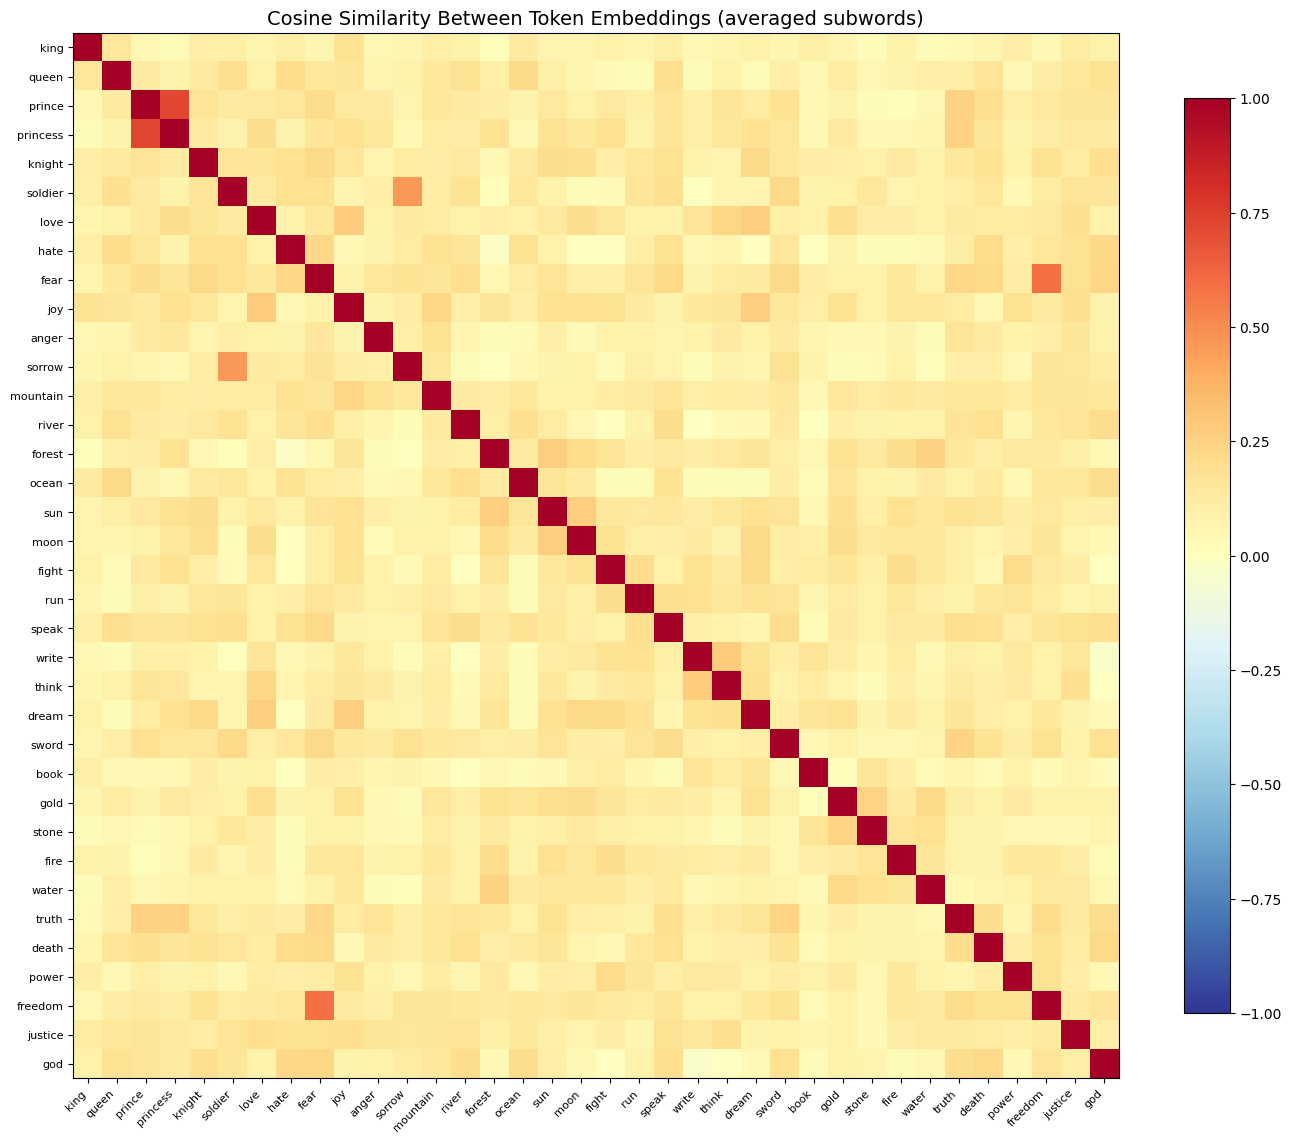

In [10]:
# Bonus: cosine similarity matrix between selected words
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(word_embeddings)

# Clean labels for display (strip BPE pieces)
display_labels = [l.split(" (")[0] for l in word_labels]

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(sim, cmap="RdYlBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(display_labels)))
ax.set_yticks(range(len(display_labels)))
ax.set_xticklabels(display_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(display_labels, fontsize=8)
ax.set_title("Cosine Similarity Between Token Embeddings (averaged subwords)", fontsize=14)
plt.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()